In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torch.utils.data import TensorDataset, DataLoader

In [2]:
data = pd.read_csv("/content/customers (1).csv")
data.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Segment
0,Male,Yes,62,No,Doctor,23,High,6,D
1,Female,Yes,49,No,Engineer,32,Low,6,B
2,Male,Yes,69,No,Engineer,28,Low,6,C
3,Male,No,47,Yes,Teacher,21,High,4,B
4,Male,No,64,No,Doctor,25,Average,4,B


In [4]:
data.columns

Index(['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Segment'],
      dtype='object')

In [9]:
if "ID" in data.columns:
    data = data.drop(columns=["ID"])
data.fillna({"Work_Experience": 0, "Family_Size": data["Family_Size"].median()}, inplace=True)


categorical_columns = ["Gender", "Ever_Married", "Graduated", "Profession", "Spending_Score"]
for col in categorical_columns:
    data[col] = LabelEncoder().fit_transform(data[col])


# Encode target variable
label_encoder = LabelEncoder()
data["Segment"] = label_encoder.fit_transform(data["Segment"])  # A, B, C, D -> 0, 1, 2, 3


# Split features and target
X = data.drop(columns=["Segment"])
y = data["Segment"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


# Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)


#Name: SANTHOSH KUMAR A
#Register Number: 212224230250
class PeopleClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(PeopleClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, num_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x



input_size = X_train.shape[1]
num_classes = 4

model = PeopleClassifier(input_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


def train_model(model, train_loader, criterion, optimizer, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")



train_model(model, train_loader, criterion, optimizer, epochs=50)

Epoch 1/50, Loss: 20.9578
Epoch 2/50, Loss: 20.8469
Epoch 3/50, Loss: 20.7922
Epoch 4/50, Loss: 20.7077
Epoch 5/50, Loss: 20.6497
Epoch 6/50, Loss: 20.6012
Epoch 7/50, Loss: 20.5302
Epoch 8/50, Loss: 20.4680
Epoch 9/50, Loss: 20.4167
Epoch 10/50, Loss: 20.3581
Epoch 11/50, Loss: 20.2886
Epoch 12/50, Loss: 20.2305
Epoch 13/50, Loss: 20.1645
Epoch 14/50, Loss: 20.0866
Epoch 15/50, Loss: 20.0372
Epoch 16/50, Loss: 19.9507
Epoch 17/50, Loss: 19.8834
Epoch 18/50, Loss: 19.8204
Epoch 19/50, Loss: 19.7470
Epoch 20/50, Loss: 19.6588
Epoch 21/50, Loss: 19.5787
Epoch 22/50, Loss: 19.5188
Epoch 23/50, Loss: 19.4299
Epoch 24/50, Loss: 19.3463
Epoch 25/50, Loss: 19.2437
Epoch 26/50, Loss: 19.1419
Epoch 27/50, Loss: 19.0602
Epoch 28/50, Loss: 18.9739
Epoch 29/50, Loss: 18.8898
Epoch 30/50, Loss: 18.8025
Epoch 31/50, Loss: 18.7183
Epoch 32/50, Loss: 18.6384
Epoch 33/50, Loss: 18.5493
Epoch 34/50, Loss: 18.4925
Epoch 35/50, Loss: 18.3960
Epoch 36/50, Loss: 18.2904
Epoch 37/50, Loss: 18.2262
Epoch 38/5

In [10]:
model.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        y_pred.extend(predicted.numpy())
        y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)
print(cm)



[[3 5 8 2]
 [1 4 9 3]
 [2 3 5 1]
 [4 4 2 4]]


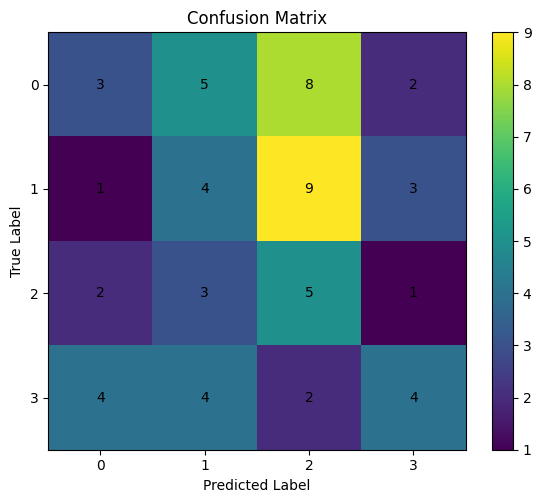

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Plot confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

classes = label_encoder.classes_
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add values inside the matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.tight_layout()
plt.show()

In [12]:
print(classification_report(y_true, y_pred, target_names=[str(c) for c in label_encoder.classes_]))

              precision    recall  f1-score   support

           0       0.30      0.17      0.21        18
           1       0.25      0.24      0.24        17
           2       0.21      0.45      0.29        11
           3       0.40      0.29      0.33        14

    accuracy                           0.27        60
   macro avg       0.29      0.29      0.27        60
weighted avg       0.29      0.27      0.26        60



In [14]:
import numpy as np
sample = np.array([[1, 0, 45, 1, 0, 2, 3, 4]])
sample = scaler.transform(sample)
sample = torch.tensor(sample, dtype=torch.float32)

output = model(sample)
_, prediction = torch.max(output, 1)

print("Predicted Segment:", label_encoder.inverse_transform(prediction.numpy()))

Predicted Segment: [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
